In [1]:
import pandas as pd
import numpy as np

nav_history = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [2]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

print(nav_history.dtypes)

amfi_code             int64
date         datetime64[ns]
nav                 float64
dtype: object


In [3]:
nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_history.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [4]:
nav_history["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

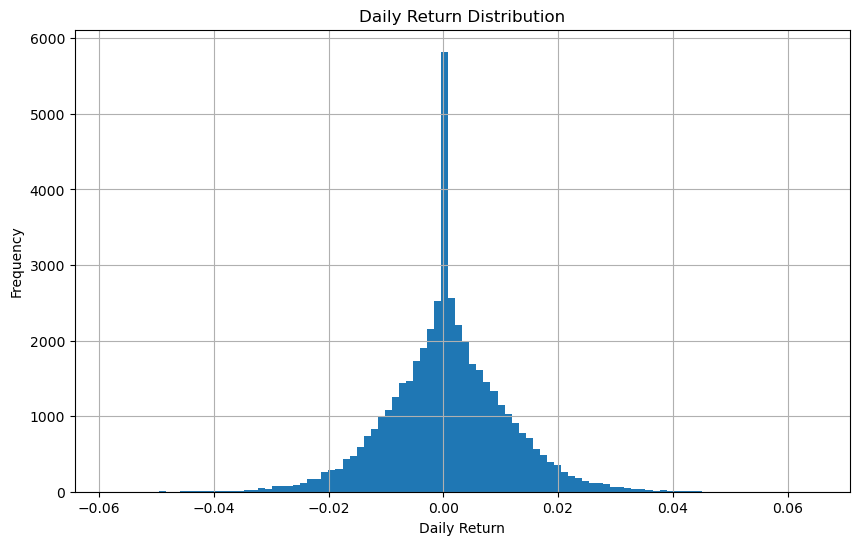

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

nav_history["daily_return"].hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [6]:
cagr_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].sort_values("date")

    start_nav = fund_data.iloc[0]["nav"]
    end_nav = fund_data.iloc[-1]["nav"]

    years = (
        (fund_data.iloc[-1]["date"] -
         fund_data.iloc[0]["date"]).days
    ) / 365

    cagr = (
        (end_nav / start_nav) ** (1 / years)
    ) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["amfi_code", "cagr"]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
cagr_df = cagr_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

cagr_df = cagr_df.sort_values(
    "cagr",
    ascending=False
)

cagr_df.head(10)

,amfi_code,cagr,scheme_name
25,120505,0.328016,ICICI Pru Midcap Fund - Regular - Growth
21,119598,0.323981,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.322621,DSP Small Cap Fund - Regular - Growth
36,148569,0.319245,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,0.309499,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.308833,Kotak Flexicap Fund - Regular - Growth
2,100033,0.300997,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,0.295581,DSP Midcap Fund - Regular - Growth
16,119094,0.281926,Axis Midcap Fund - Regular - Growth
19,119551,0.257849,SBI Bluechip Fund - Regular Plan - Growth


In [8]:
cagr_df.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR table saved")

CAGR table saved


In [9]:
cagr_df.head(5)

,amfi_code,cagr,scheme_name
25,120505,0.328016,ICICI Pru Midcap Fund - Regular - Growth
21,119598,0.323981,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.322621,DSP Small Cap Fund - Regular - Growth
36,148569,0.319245,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,0.309499,Mirae Asset Large Cap Fund - Regular - Growth


In [10]:
rf = 0.065

sharpe_results = []

for fund in nav_history["amfi_code"].unique():

    fund_returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = (
        fund_returns.mean() * 252
    )

    annual_volatility = (
        fund_returns.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_results.append(
        [fund, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["amfi_code", "sharpe_ratio"]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [11]:
sharpe_df = sharpe_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [12]:
sharpe_df.to_csv(
    "../reports/sharpe_ranking.csv",
    index=False
)

print("Sharpe ranking saved")

Sharpe ranking saved


In [13]:
sharpe_df.head(5)

,amfi_code,sharpe_ratio,scheme_name
34,148567,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,ICICI Pru Midcap Fund - Regular - Growth


In [14]:
rf = 0.065

sortino_results = []

for fund in nav_history["amfi_code"].unique():

    returns = nav_history[
        nav_history["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < 0]

    downside_std = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_std

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [15]:
sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [16]:
sortino_df.to_csv(
    "../reports/sortino_ranking.csv",
    index=False
)

print("Sortino ranking saved")

Sortino ranking saved


In [17]:
sortino_df.head(5)

,amfi_code,sortino_ratio,scheme_name
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth


In [18]:
benchmark["index_name"].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [19]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [20]:
from scipy.stats import linregress

In [21]:
alpha_beta_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_data,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta_results.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [22]:
alpha_beta_df = alpha_beta_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [23]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth
16,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth
19,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth


In [24]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [25]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(5)

,amfi_code,alpha,beta,scheme_name
21,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth
25,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth


In [26]:
drawdown_results = []

for fund in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    fund_data = fund_data.sort_values("date")

    fund_data["running_max"] = (
        fund_data["nav"].cummax()
    )

    fund_data["drawdown"] = (
        fund_data["nav"]
        / fund_data["running_max"]
        - 1
    )

    max_dd = fund_data["drawdown"].min()

    drawdown_results.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [27]:
drawdown_df = drawdown_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

drawdown_df.head()

,amfi_code,max_drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [28]:
drawdown_df.sort_values(
    "max_drawdown"
).head(10)

,amfi_code,max_drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth


In [29]:
drawdown_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

print("Drawdown file saved")

Drawdown file saved


In [30]:
drawdown_df.sort_values(
    "max_drawdown"
).head(5)

,amfi_code,max_drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth


In [31]:
scorecard = performance[
    [
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "expense_ratio_pct"
    ]
].copy()

In [32]:
scorecard = scorecard.merge(
    sharpe_df[
        ["amfi_code", "sharpe_ratio"]
    ],
    on="amfi_code"
)

In [33]:
scorecard = scorecard.merge(
    alpha_beta_df[
        ["amfi_code", "alpha"]
    ],
    on="amfi_code"
)

In [34]:
scorecard = scorecard.merge(
    drawdown_df[
        ["amfi_code", "max_drawdown"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,12.36,1.54,1.208267,0.232010,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,11.30,0.66,0.953279,0.198686,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.72,-0.057187,0.048824,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,6.07,0.77,-0.226575,0.056209,-0.043287


In [35]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [36]:
scorecard["fund_score"] = (
      scorecard["return_rank"] * 0.30
    + scorecard["sharpe_rank"] * 0.25
    + scorecard["alpha_rank"] * 0.20
    + scorecard["expense_rank"] * 0.15
    + scorecard["dd_rank"] * 0.10
)

In [37]:
scorecard["fund_score"] = (
    100
    * (
        scorecard["fund_score"].max()
        - scorecard["fund_score"]
    )
    / (
        scorecard["fund_score"].max()
        - scorecard["fund_score"].min()
    )
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,return_3yr_pct,expense_ratio_pct,sharpe_ratio,alpha,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.36,1.180101,0.292636,-0.181885,8.0,5.0,3.0,15.0,25.0,100.000000
22,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.45,1.306744,0.273305,-0.129740,11.0,2.0,5.0,22.0,13.0,98.143852
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.38,1.093699,0.271954,-0.162172,10.0,7.0,6.0,17.0,20.0,93.039443
2,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,1.43,0.945308,0.303370,-0.287060,1.0,14.0,1.0,21.0,36.0,91.879350
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.46,1.448291,0.269838,-0.112657,17.0,1.0,7.0,23.0,8.0,90.719258
39,149324,DSP Small Cap Fund - Regular - Growth,20.08,1.52,0.949796,0.300579,-0.311719,6.0,13.0,2.0,26.5,37.0,80.858469
38,149323,DSP Midcap Fund - Regular - Growth,17.16,1.61,1.132122,0.265986,-0.172481,9.0,6.0,8.0,38.0,22.0,78.190255
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,0.80,1.026524,0.211948,-0.125883,20.0,10.0,13.0,12.0,12.0,76.334107
26,119094,Axis Midcap Fund - Regular - Growth,15.18,1.38,0.998231,0.260767,-0.209609,15.0,11.0,9.0,17.0,28.0,74.941995
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.60,1.234930,0.282704,-0.163967,23.0,3.0,4.0,36.5,21.0,67.401392


In [38]:
scorecard[
    ["scheme_name", "fund_score"]
].head(5)

,scheme_name,fund_score
12,ICICI Pru Midcap Fund - Regular - Growth,100.000000
22,Kotak Flexicap Fund - Regular - Growth,98.143852
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,93.039443
2,SBI Small Cap Fund - Regular Plan - Growth,91.879350
34,Mirae Asset Large Cap Fund - Regular - Growth,90.719258


In [39]:
top5_funds = scorecard["amfi_code"].head(5).tolist()

top5_funds

[120505, 120843, 100033, 119598, 148567]

In [40]:
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

print(nifty50.shape)
print(nifty100.shape)

(1150, 3)
(1150, 3)


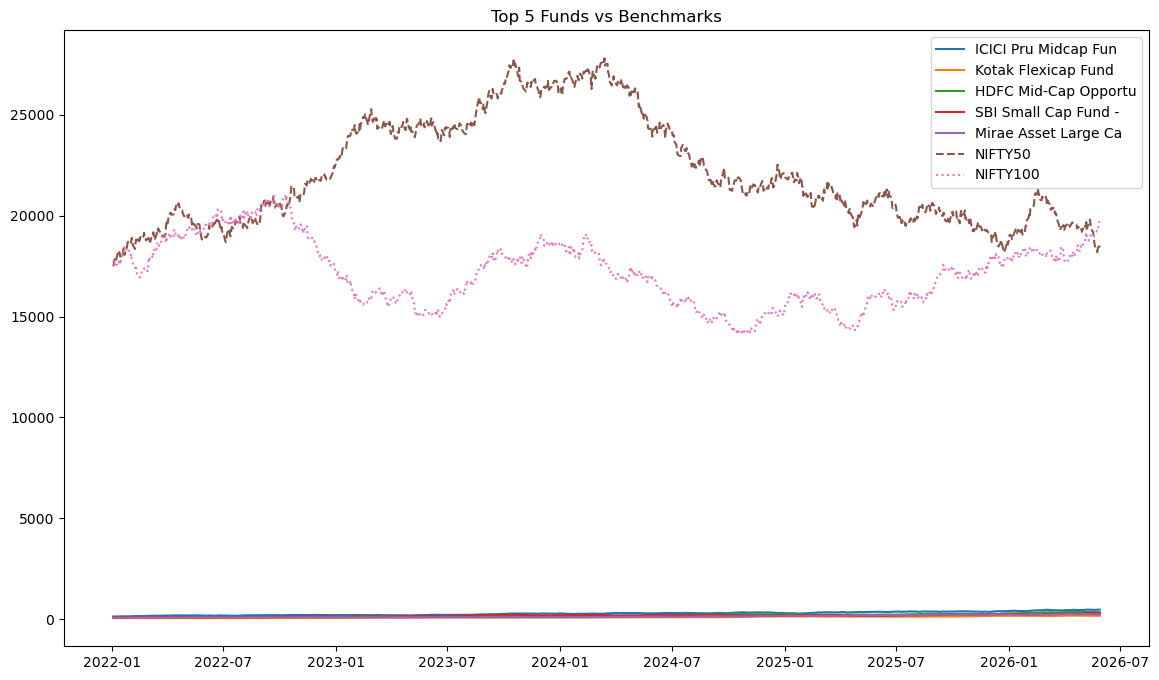

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

for fund in top5_funds:

    fund_data = nav_history[
        nav_history["amfi_code"] == fund
    ].copy()

    fund_name = fund_master.loc[
        fund_master["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        label=fund_name[:20]
    )

plt.plot(
    nifty50["date"],
    nifty50["close_value"],
    linestyle="--",
    label="NIFTY50"
)

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linestyle=":",
    label="NIFTY100"
)

plt.title("Top 5 Funds vs Benchmarks")

plt.legend()

plt.show()

In [42]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved
